
$$
\Large{\textbf{
  Pollutant dispersion: deterministic and stochastic models
  }}
$$

$$
\large{\text{
  Johannes Löppönen, Arvid Hedin, Elis Graipe
  }}
$$
$$
\large{\text{
  MiniProject Group 3
}}
$$
$$
\ \\
\ \\
\ \\
\ \\
\ \\
$$

# Introduction


This project aims to model the dispersion of pollutant particles in air, from combustion. The dispersion can be described using a partial differential equation but in this project the dispersion will be modeled using a stochastic simulation utilizing a random walk for each pollutant particle.



# Approach and method

The mathematical modeling of pollutant dispersion relies on a difference in view models from macroscopic and microscopic perspectives. In the macroscopic viewpoint the pollutant is viewed as a concentration field $C(x, t)$, whose change is determined by the deterministic advection-diffusion equation:

$$\frac{\partial C}{\partial t} + \nabla \cdot (uC) = D\nabla^{2}C$$

This formulation handles the transport process as a continuous flow where the term $\nabla \cdot (uC)$ represents the advective change in position described by the velocity field u, and $D\nabla^{2}C$ describes the diffusion which is governed by the constant D which determines the velocity of the spread. This perspective is deterministic, which gives a predictable description of the pollutants change over time.

For contrast, the microscopic viewpoint instead focuses on the direction of each individual particle X(t). The motion is now instead described by an Itô stochastic differential equation.

$$dX(t) = u(X(t), t)dt + \sqrt{2D}dB(t)$$

In this case the particle's movement is the result of the deterministic advection component and a stochastic diffusion component given by Brownian motion B(t). This results in the path of any single particle being random and unpredictable.

The connection between these two models is provided by the Fokker-Planck equation. This equation says that the probability density function f(x, t), of the particles trajectory satisfies the same PDE as in the macroscopic concentration field.

This leads to the deterministic plume we observe at a large scale being the statistical result of thousands of independent, random particle scale occurances. In this project, we use this link by simulating an sum of particles and using a Monte Carlo approximated Gaussian kernel $\delta_{\epsilon}$ to visualize the continuous concentration field.

$$C(x, t) \approx \frac{1}{N} \sum_{k=1}^{N} \delta_{\epsilon}(x - X^{k}(t))$$

This way of modeling illustrates how a complex process can be split up into simple stochastic rules and applied individual particles. This as a concequence allows for concentration field to be estimated through Monte Carlo simulation rather than direct numerical solving of the PDE.

# Results


## Task 1


## Numerical simulation

The Euler-Maruyama method is implemented to solve the stochastic differential equation (SDE) in Task 1. The Euler-Maruyama method is used to numerically integrate the SDE. It integrates the SDE over time for $N$ particles that are independent of each other. 

The iterative method that describes the next position in time for the particles following a starting position $X_0$ is give by

$\mathbf{X}_{n+1} = \mathbf{X}_n + \mathbf{u}h + \sqrt{2Dh}\mathbf{Z}_n, \quad \mathbf{z}_n \sim \mathcal{N}(\mathbf{0}, I_2)$

where $h$ is the time step and $I_2$ is the identity matrix.

In the code the function *euler* implements the above Euler-Maruyama method. It simulates the positions for $N$ particles in the time interval $[0, T]$. The function returns a list of arrays with the positions of the particles at the times specified by the function argument snapshots.

Using the implementation of the Euler-Maruyama method in the *euler* function we compute the positions of $N$ number of particles at different times $T$ after 0. The particles originate at the point $\mathbf{X}_0 = (0,0)$ and are visualized in a plot showing how the particles have dispersed by $T$ seconds. The area shown is a rectangle constrained to $x \in [0, 25], \quad y \in [-5, 5]$. The constants and function arguments are defined as follows.

We assume that the dispersion constant and velocity vector are constants and do not depend on time or position. This is not entirely realistic as these are likely to vary in the real world when taking atmospheric conditions into account.
We also assume that the particles exist at $t=0$ and that no new particles are released there after.

By calling the euler function with four different end times in checkpoints the following snapshots can be plotted from which we can observe how the pollutant particles diffuse.

## Task 2


For the second task the purpose is to compute and visualize the concentration of pollutant particles in the same rectangular domain as the in previous task.

The concentration of pollutant particles is performed using the Monte Carlo method on the following formula
$C(\mathbf{x},t) \approx \frac{1}{N} \sum_{k=1}^N \delta_{\epsilon} (\mathbf{x}-\mathbf{X}^k(t))$
where $\mathbf{X}$ is a random variable $\mathbf{x}$ is the current position of a particle and $\delta_\epsilon$ is the Dirac delta distribution.

In the code we create an approximation of the Dirac delta distribution to avoid problems with infinity. This approximation is provided by the function *delta_eps*.

The Monte Carlo method described above is implemented in the function *compute_concentration*. This function takes in the computed particle distribution snapshots, computed by the *euler* function, runs the Monte Carlo simulations and returns an array with the concentrations at the coordinates provided by the function arguments for each snapshot (point in time).

One assumption that has been made in this computation is that the number of particles is big enough for the Monte Carlo method to give a sufficiently good result as it is not possible to run the method more than $N$ times.

Using the results from the previous task we can now plot the concentration of pollutant particles in the same domain from *compute_concentration* using a surface contour plot.

## Task 3


A more realistic simulation of pollutant dispersion often includes a source term which takes into account that the pollutants often are released continuously from a chimney for example.

The function *euler* takes this into account by including an argument for a source term and adds the amount of pollutant particles that are released in between each time step during each iteration.

To study how the pollutant particles and their concentration behaves when they are continuously released we simply need to re-run the simulations from earlier with new constants and function arguments.

The model assumes a constant release rate from the source as well as constant dispersion and initial velocity.

Similarly, the concentration field can be plotted with the source term.

# Discussion


The simulation results are heavily influenced by the parameters D, u, and Q, each representing a distinct physical mechanism in the transport of pollutants. The diffusion coefficient D represents molecular agitation and random motion; a value of zero results in no spreading, while increasing D causes the particle cloud to expand more rapidly, leading to lower concentrations. The velocity field u represents deterministic transport by fluid flow, determining the cloud's center of mass trajectory without affecting its expansion rate. Finally, the emission rate Q defines the pollutant source strength, where a non-zero Q in Task 3 represents a continuous source like an exhaust pipe, creating a steady-state output with peak concentrations at the source location.

This project highlights the complementarity between the macroscopic Eulerian viewpoint (PDE) and the microscopic Lagrangian viewpoint (SDE). The advection-diffusion equation provides a mathematically rigorous, smooth representation of density but can be computationally demanding. In contrast, the stochastic approach uses Itô differential equations to simulate individual particle trajectories, which is often easier to implement for complex scenarios like continuous injection without requiring a mesh. However, a key challenge in this method is the choice of the smoothing parameter ϵ; a value too small makes the field appear noisy, while one too large artificially flattens concentration peaks.

The simulation results across different tasks demonstrate how advection and diffusion jointly determine the pollutant's shape. While advection pushes the cloud along the x-axis, diffusion causes it to expand in all directions, decreasing peak concentration over time. The most striking difference appears between the instantaneous release in Tasks 1 and 2 and the continuous release in Task 3. In the former, the cloud remains roughly circular as it expands and drifts. In the latter, the constant injection of particles fills the space between the source and the leading edge, forming a characteristic cone-shaped plume typically seen in atmospheric dispersion.

# Appendix


In [56]:
import numpy as np
import matplotlib.pyplot as plt

In [57]:
def euler(N, T, h, D, u, num_steps, checkpoints, q):
    X = np.zeros((N, 2))
    particles_per_step = int(q * h) 
    t = np.linspace(0, T, num_steps + 1)

    snapshots = []

    for n in range(num_steps + 1):
        new_particles = np.zeros((particles_per_step, 2))
        X = np.vstack([X, new_particles])
        
        num_active = X.shape[0]
        Z = np.random.randn(num_active, 2)
        X = X + u * h + np.sqrt(2 * D * h) * Z        
        
        if any(np.isclose(t[n], checkpoints)):
            snapshots.append(X.copy())

    return snapshots

In [58]:
# Constants

N = 2000         
T = 60       
h = 0.1         
D = 0.02
epsilon = 0.1

u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

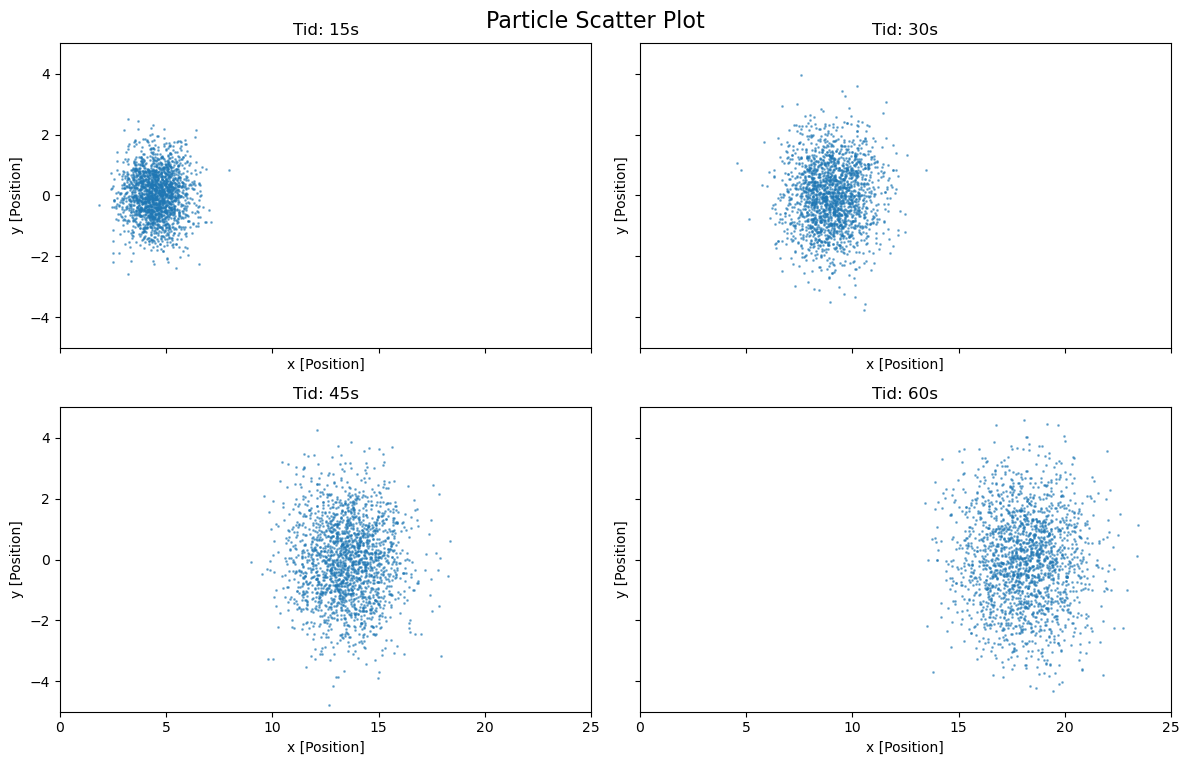

In [59]:
# Plot

snapshots = euler(N,T,h,D,u,num_steps, checkpoints, 0) # No source term
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x [Position]")
    axes[i].set_ylabel("y [Position]")

plt.suptitle('Particle Scatter Plot', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

In [60]:
def delta_eps(dist, epsilon):
    fac = 1/(2*np.pi*epsilon**2)
    e = np.exp(-dist / (2*epsilon**2))
    return fac * e

def compute_concentration(x_grid, y_grid, snapshot, epsilon):
    N = snapshot.shape[0] #Amount of particles at time t
    C = np.zeros(x_grid.shape)

    for k in range(N):
        dist = ((x_grid - snapshot[k,0])**2 + (y_grid - snapshot[k,1])**2)
        C += delta_eps(dist, epsilon)

    return C / N

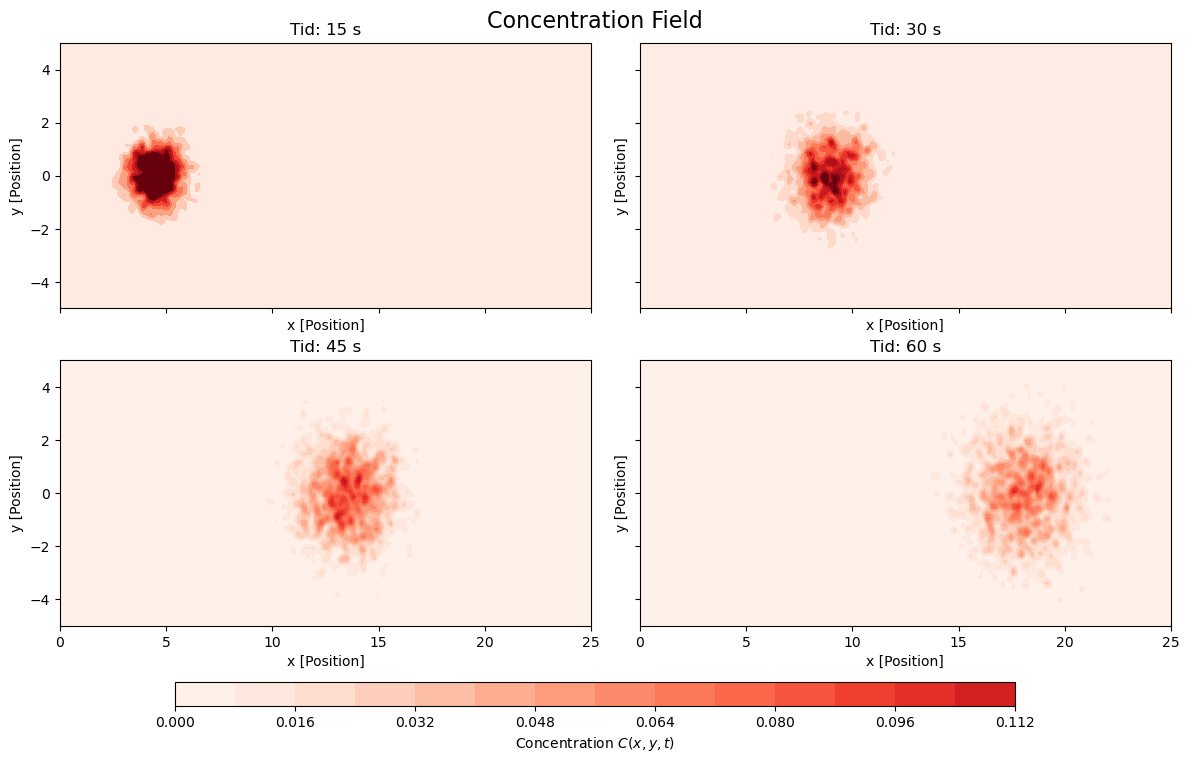

In [61]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.15

for i in range(len(snapshots)): # Snapshots is the results from Task 1
    X = snapshots[i]
    C = compute_concentration(x_grid, y_grid, X, epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=15, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x [Position]")
    axes[i].set_ylabel("y [Position]")

plt.suptitle('Concentration Field', fontsize=16, y=0.95)
plt.tight_layout()

fig.subplots_adjust(bottom=0.18)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Concentration $C(x,y,t)$')

plt.show()

In [62]:
# Constants
N = 0         
T = 60       
h = 0.1         
D = 0.02     
Q = 100    
u = np.array([0.3, 0]) 
num_steps = int(T / h)
checkpoints = [15, 30, 45, 60]

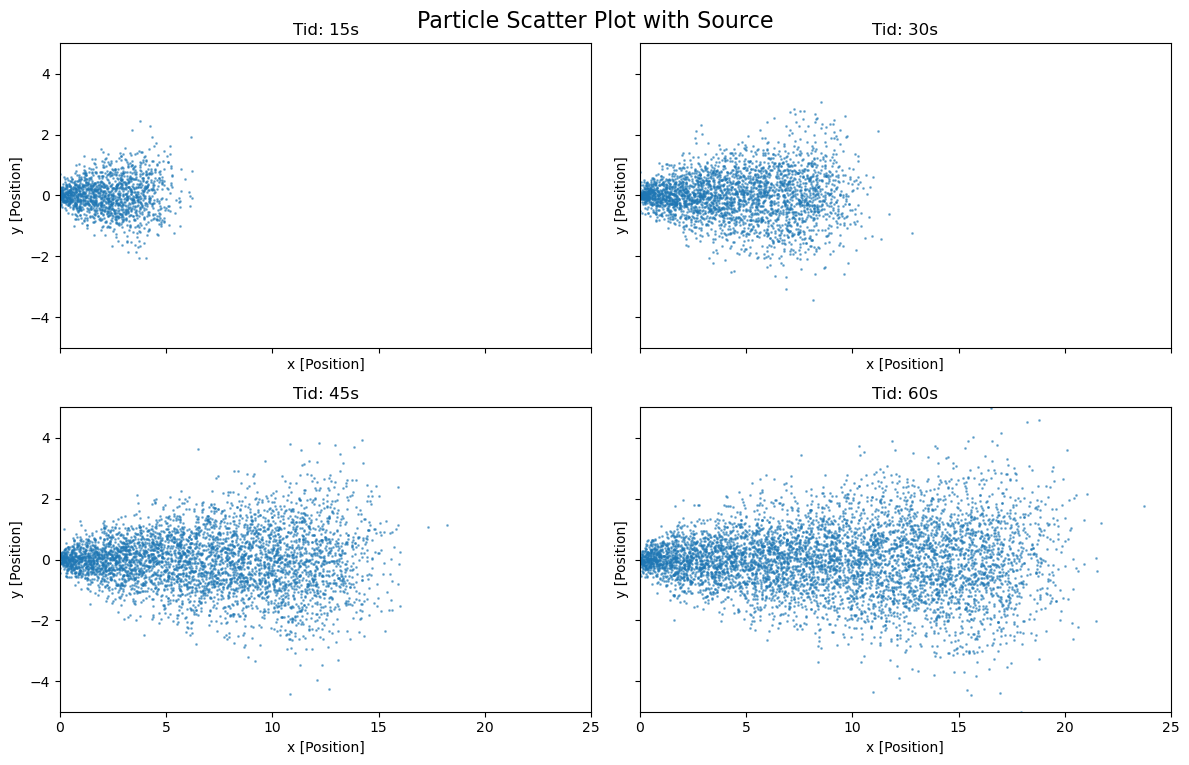

In [63]:
snapshots = euler(N,T,h,D,u,num_steps, checkpoints,Q)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, t in enumerate(checkpoints):
    pos = snapshots[i]
    axes[i].scatter(pos[:, 0], pos[:, 1], s=1, alpha=0.5)
    axes[i].set_title(f"Tid: {t}s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x [Position]")
    axes[i].set_ylabel("y [Position]")

plt.suptitle('Particle Scatter Plot with Source', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

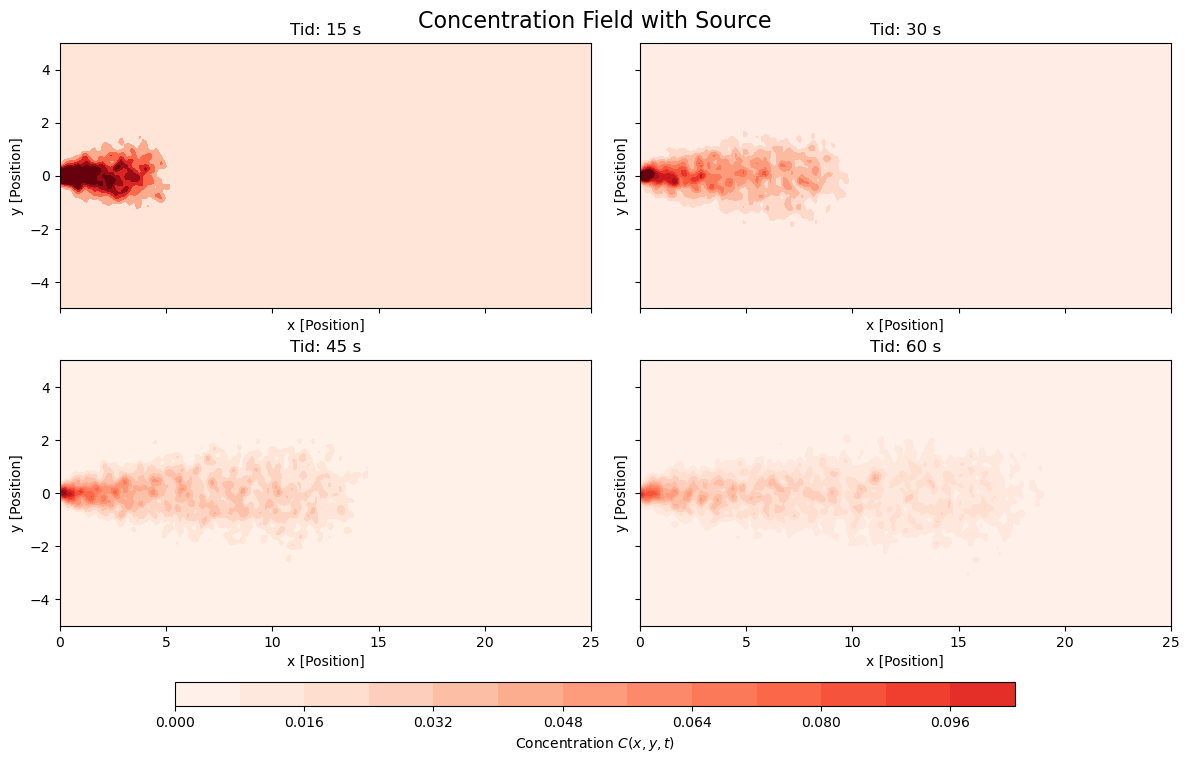

In [64]:
# Setup grid
nx, ny = (200, 100)
x = np.linspace(0, 25, nx)
y = np.linspace(-5, 5, ny)
x_grid, y_grid = np.meshgrid(x, y)

# Plot concentrations
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()
vmin, vmax = 0, 0.15

for i in range(len(snapshots)):
    C = compute_concentration(x_grid, y_grid, snapshots[i], epsilon)
    contour = axes[i].contourf(x_grid, y_grid, C, levels=15, 
                               cmap='Reds', vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Tid: {checkpoints[i]} s")
    axes[i].set_xlim(0, 25)
    axes[i].set_ylim(-5, 5)  
    axes[i].set_xlabel("x [Position]")
    axes[i].set_ylabel("y [Position]")

plt.suptitle('Concentration Field with Source', fontsize=16, y=0.95)
plt.tight_layout()

fig.subplots_adjust(bottom=0.18)
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.03])
fig.colorbar(contour, cax=cbar_ax, orientation='horizontal', label='Concentration $C(x,y,t)$')

plt.show()